In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, optimizers, datasets, utils

## PART A: MULTILAYER PERCEPTRON (MLP)

#### Example 2-1:

In [2]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

NUM_CLASSES = 10

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = utils.to_categorical(y_train, NUM_CLASSES)
y_test = utils.to_categorical(y_test, NUM_CLASSES)

print("x_train shape:", x_train.shape)
print("x_test shape :", x_test.shape)
print("y_train shape:", y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 461s 3us/step
x_train shape: (50000, 32, 32, 3)
x_test shape : (10000, 32, 32, 3)
y_train shape: (50000, 10)


#### Example 2-2:

In [3]:
print(x_train[54, 12, 13, 1])

0.36862746


#### Example 2-3:

In [4]:
sequential_model = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(200, activation="relu"),
    layers.Dense(150, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


#### Example 2-4:

In [ ]:
input_layer = layers.Input(shape=(32, 32, 3))
x = layers.Flatten()(input_layer)
x = layers.Dense(units=200, activation="relu")(x)
x = layers.Dense(units=150, activation="relu")(x)
output_layer = layers.Dense(units=10, activation="softmax")(x)
model = models.Model(input_layer, output_layer)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 200)            │       614,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 150)            │        30,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,260 (2.47 MB)

 Trainable params: 646,260 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

#### Example 2-5:

In [6]:
# Illustrative only, not used in trained model
# x = layers.Dense(units=200, activation='relu')(x)

#### Example 2-6:

In [7]:
# Illustrative only, not used in trained model
# x = layers.Dense(units=200)(x)
# x = layers.Activation('relu')(x)

#### Example 2-7:

In [8]:
opt = optimizers.Adam(learning_rate=0.0005)
model.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])

#### Example 2-8:

In [9]:
model.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=10,
    shuffle=True,
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.3331 - loss: 1.8466
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4031 - loss: 1.6622
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4333 - loss: 1.5822
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4548 - loss: 1.5301
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4689 - loss: 1.4878
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4819 - loss: 1.4573
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4912 - loss: 1.4270
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4975 - loss: 1.4057
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5103 - loss: 1.3817
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.5152 - loss: 1.3636


#### Example 2-9:

In [22]:
mlp_test_results = model.evaluate(x_test, y_test)
print("\nMLP test loss, test accuracy:", mlp_test_results)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5000 - loss: 1.4127

MLP test loss, test accuracy: [1.4127312898635864, 0.5]


#### Example 2-10:

In [11]:
CLASSES = np.array(
    ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
)

preds = model.predict(x_test)
preds_single = CLASSES[np.argmax(preds, axis=-1)]
actual_single = CLASSES[np.argmax(y_test, axis=-1)]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


#### Example 2-11:

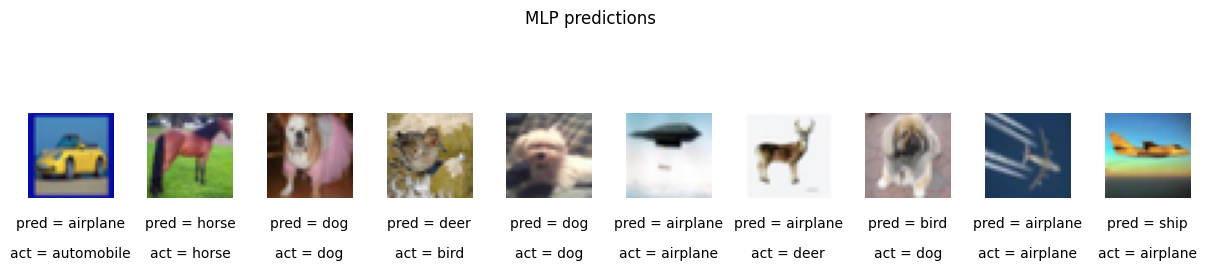

In [12]:
n_to_show = 10
indices = np.random.choice(range(len(x_test)), n_to_show)

fig = plt.figure(figsize=(15, 3))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

for i, idx in enumerate(indices):
    img = x_test[idx]
    ax = fig.add_subplot(1, n_to_show, i + 1)
    ax.axis("off")
    ax.text(0.5, -0.35, "pred = " + str(preds_single[idx]), fontsize=10, ha="center", transform=ax.transAxes)
    ax.text(0.5, -0.7, "act = " + str(actual_single[idx]), fontsize=10, ha="center", transform=ax.transAxes)
    ax.imshow(img)

plt.suptitle("MLP predictions")
plt.savefig("mlp_predictions.png")
plt.show()

## PART B: CONVOLUTIONAL NEURAL NETWORK (CNN)

#### Example 2-12:

In [13]:
# Illustrative
demo_input = layers.Input(shape=(64, 64, 1))
demo_conv = layers.Conv2D(
    filters=2,
    kernel_size=(3, 3),
    strides=1,
    padding="same")(demo_input)

#### Example 2-13:

In [14]:
# Illustrative
small_cnn_input = layers.Input(shape=(32, 32, 3))
conv_layer_1 = layers.Conv2D(
    filters=10,
    kernel_size=(4, 4),
    strides=2,
    padding="same")(small_cnn_input)
conv_layer_2 = layers.Conv2D(
    filters=20,
    kernel_size=(3, 3),
    strides=2,
    padding="same")(conv_layer_1)
flatten_layer = layers.Flatten()(conv_layer_2)
small_cnn_output = layers.Dense(units=10, activation="softmax")(flatten_layer)
small_cnn_model = models.Model(small_cnn_input, small_cnn_output)
small_cnn_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 10)     │           490 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 20)       │         1,820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,120 (59.06 KB)

 Trainable params: 15,120 (59.06 KB)

 Non-trainable params: 0 (0.00 B)

#### Example 2-14:

In [15]:
# Used directly inside full CNN below
# layers.BatchNormalization(momentum=0.9)

#### Example 2-15:

In [16]:
# Used directly inside full CNN below
# layers.Dropout(rate=0.25)

#### Example 2-16:

In [17]:
input_layer = layers.Input((32, 32, 3))

x = layers.Conv2D(filters=32, kernel_size=3, strides=1, padding="same")(input_layer)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

x = layers.Conv2D(filters=32, kernel_size=3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

x = layers.Conv2D(filters=64, kernel_size=3, strides=1, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

x = layers.Conv2D(filters=64, kernel_size=3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

x = layers.Flatten()(x)

x = layers.Dense(128)(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
x = layers.Dropout(rate=0.5)(x)

cnn_output_layer = layers.Dense(10, activation="softmax")(x)

cnn_model = models.Model(input_layer, cnn_output_layer)
cnn_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,554 (2.26 MB)

 Trainable params: 591,914 (2.26 MB)

 Non-trainable params: 640 (2.50 KB)

#### Training and Evaluating the CNN

In [19]:
cnn_opt = optimizers.Adam(learning_rate=0.0005)
cnn_model.compile(loss="categorical_crossentropy", optimizer=cnn_opt, metrics=["accuracy"])

cnn_model.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=10,
    shuffle=True,
)

cnn_model.evaluate(x_test, y_test)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 147s 91ms/step - accuracy: 0.5994 - loss: 1.1352
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 204s 92ms/step - accuracy: 0.6583 - loss: 0.9760
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 200s 91ms/step - accuracy: 0.6877 - loss: 0.8957
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 202s 91ms/step - accuracy: 0.7080 - loss: 0.8364
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 91ms/step - accuracy: 0.7256 - loss: 0.7900
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 201s 91ms/step - accuracy: 0.7407 - loss: 0.7442
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 91ms/step - accuracy: 0.7533 - loss: 0.7064
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 91ms/step - accuracy: 0.7641 - loss: 0.6752
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 91ms/step - accuracy: 0.7721 - loss: 0.6487
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 202s 91ms/step - accuracy: 0.7863 - loss: 0.6157
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7304 - loss: 0.7863


[0.786315381526947, 0.730400025844574]

In [23]:
cnn_test_results = cnn_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.7304 - loss: 0.7863


#### Predictions from the CNN

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step


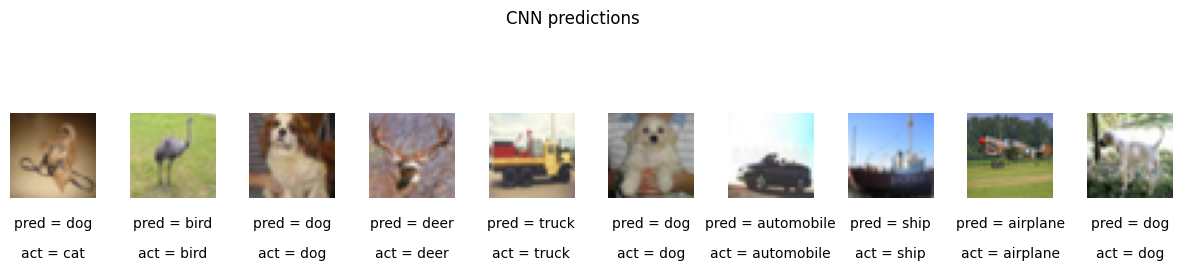

In [20]:
cnn_preds = cnn_model.predict(x_test)
cnn_preds_single = CLASSES[np.argmax(cnn_preds, axis=-1)]

indices = np.random.choice(range(len(x_test)), n_to_show)
fig = plt.figure(figsize=(15, 3))
fig.subplots_adjust(hspace=0.4, wspace=0.4)
for i, idx in enumerate(indices):
    img = x_test[idx]
    ax = fig.add_subplot(1, n_to_show, i + 1)
    ax.axis("off")
    ax.text(0.5, -0.35, "pred = " + str(cnn_preds_single[idx]), fontsize=10, ha="center", transform=ax.transAxes)
    ax.text(0.5, -0.7, "act = " + str(actual_single[idx]), fontsize=10, ha="center", transform=ax.transAxes)
    ax.imshow(img)
plt.suptitle("CNN predictions")
plt.savefig("cnn_predictions.png")
plt.show()

## Summary / comparison

In [24]:
print("\n===== SUMMARY =====")
print(f"MLP test accuracy: {mlp_test_results[1]*100:.1f}%")
print(f"CNN test accuracy: {cnn_test_results[1]*100:.1f}%")
print("The CNN outperforms the MLP with FEWER parameters, because convolutional, batch-normalization,")
print("and dropout layers exploit the spatial structure of images and reduce overfitting, whereas the MLP")
print("simply flattens the image and treats every pixel as an independent input feature.")


===== SUMMARY =====
MLP test accuracy: 50.0%
CNN test accuracy: 73.0%
The CNN outperforms the MLP with FEWER parameters, because convolutional, batch-normalization,
and dropout layers exploit the spatial structure of images and reduce overfitting, whereas the MLP
simply flattens the image and treats every pixel as an independent input feature.
